<font color=#85C1E9 size=8>**Predictive Model**

<font color=#858FE9 size=4>**Machine learning-based Chagas disease diagnostic tool with proteomic profiles**
    
<font color=#9085E9 size=3>**Proyecto de grado para optar por el titulo de Quimica** 

<font color=#9085E9 size=3>**Universidad Industrial de santander** 

<font color=#AD85E9 size=3>**Yenny Velandia**

<font color=#858FE1 size=6>**Samples resulting from filtration less than 3kDa**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

<font color=#AD85E9 size=4>**Spectrum reading and Loading of Dataset**

In [2]:
import glob
fn = []
all_spectra = pd.DataFrame()

data_path = r"C:\Users\nephi\Downloads\paper ML chagas\chagas\chagas\all spectra\*.txt"

for f in glob.glob(data_path):
    df = pd.read_csv(f, header=None, delimiter=' ')
    all_spectra = pd.concat([all_spectra, df], axis=1)
    fn.append(f)

# Primera columna: relación m/z
Datamz = all_spectra.iloc[:, 0].reset_index(drop=True)

# Columnas de intensidad: tomar cada segunda columna a partir de la 2
Data = all_spectra.iloc[:, 1::2].copy()

<font color=#AD85E9 size=3>**Inspección**

In [3]:
Data.columns = range(Data.shape[1])  # Índices ordenados para las columnas de intensidades
Data

Datamz.tail(10241)

# everything has signals

12799    2862.608
12800    2862.851
12801    2863.094
12802    2863.337
12803    2863.580
           ...   
23035    5887.533
23036    5887.882
23037    5888.230
23038    5888.578
23039    5888.926
Name: 0, Length: 10241, dtype: float64

<font color=#AD85E9 size=3>**m/z**

In [4]:
Dsna=Datamz[0:23040]
Dsna

0         598.375
1         598.486
2         598.597
3         598.708
4         598.819
           ...   
23035    5887.533
23036    5887.882
23037    5888.230
23038    5888.578
23039    5888.926
Name: 0, Length: 23040, dtype: float64

In [5]:
D=Dsna.isnull().any()

In [6]:
df = Data[Data[0] == True]

<font color=#AD85E9 size=3>**Intensities**

In [7]:
Dataint=Data[0:23040]
Dataint

,0,1,2,3,4,5,6,7,8,9,...,226,227,228,229,230,231,232,233,234,235
0,267,234,776,823,872,1121,-6,92,923,451,...,768,163,763,383,172,166,1213,1290,202,157
1,381,415,896,879,999,1279,223,171,1018,546,...,910,183,815,464,316,331,1221,1390,202,166
2,588,535,994,939,1025,1440,422,323,1048,656,...,932,221,796,497,369,386,1228,1484,285,115
3,735,561,910,882,854,1322,626,469,818,636,...,784,196,743,340,316,325,1233,1571,146,173
4,803,432,814,856,548,1134,539,492,807,535,...,519,136,588,302,229,235,1236,1653,61,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23035,9,15,-5,11,-6,-6,2,12,-6,9,...,-2,7,3,5,11,11,12,4,13,7
23036,7,14,-2,14,0,23,-2,12,2,20,...,8,3,-1,0,9,8,12,4,14,12
23037,15,4,3,14,17,5,6,6,-12,19,...,5,11,1,5,-3,-2,13,5,17,14
23038,-1,1,-4,29,2,7,18,6,-1,10,...,8,-3,-6,11,-3,-3,13,5,31,1


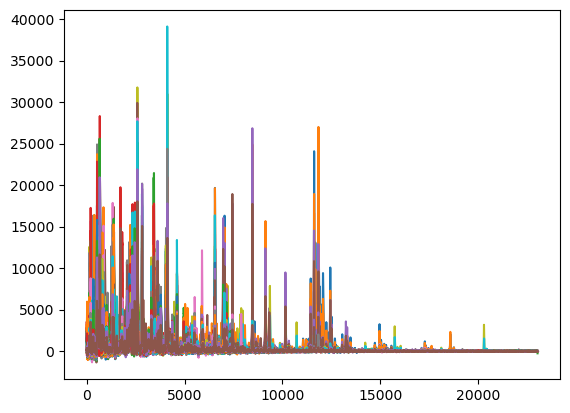

In [8]:
plt.plot(Dataint);

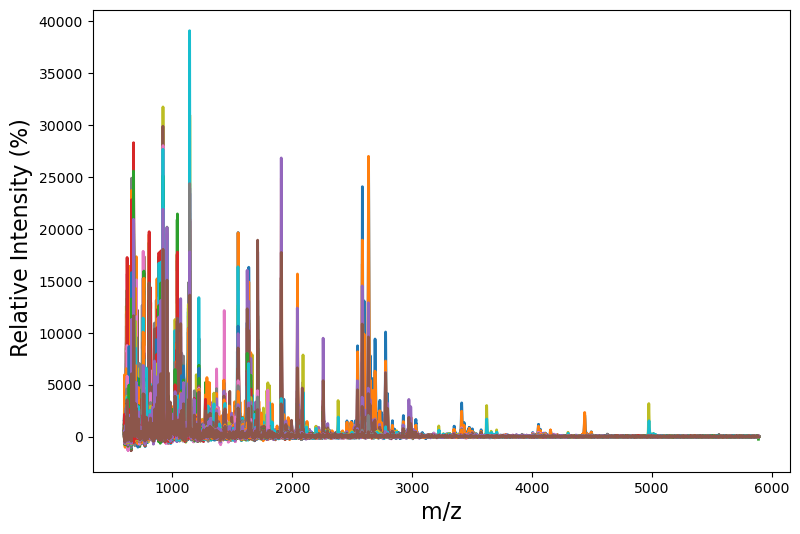

In [9]:
fig, ax = plt.subplots(figsize=(9,6))
plt.rcParams["font.family"] = 'Times New Roman'

ax.plot(Dsna, Dataint, lw=2)
ax.set_xlabel('m/z',  fontsize=16)
ax.set_ylabel(' Relative Intensity (%)', fontsize=16)
plt.savefig('espectros de masas.png')
plt.show()

In [10]:
len(Dataint.columns)

236

In [11]:
C = pd.read_excel("C:/Users/nephi/Downloads/paper ML chagas/chagas/chagas/clasificacion.xlsx")
C

,Number,clasification
0,0,A
1,1,A
2,2,N
3,3,N
4,4,S
...,...,...
231,231,A
232,232,N
233,233,N
234,234,S


In [12]:
Y= C[["clasification"]]
Y1=Y.set_axis(['Clase'], axis=1)
Y1

,Clase
0,A
1,A
2,N
3,N
4,S
...,...
231,A
232,N
233,N
234,S


<font color=#858FE1 size=6>**Principal Component Analysis (PCA)**
    
<font color=#AD85E9 size=3>**Unsupervised learning**

In [13]:
#data normalization
from sklearn.preprocessing import StandardScaler, Normalizer
scaler=StandardScaler()

scaler.fit(Dataint) # calculo la media para poder hacer la transformacion
x_scaled=scaler.transform(Dataint)# Ahora si, escalo los datos y los normalizo

In [14]:
valt=Dataint.T

valtn = preprocessing.normalize(valt, norm='l1')# Normaliza los datos
# Iniciamos el desarrollo del PCA en este caso con 10 componentes
pca=PCA(n_components=10) # Otra opción es hacer pca hasta obtener un mínimo explicado ej.: pca=PCA(.85)
pca1=pca.fit(x_scaled.T) # obtener los componentes principales
datos_pca=pca.transform(x_scaled.T) # convertimos nuestros datos con las nuevas dimensiones de PCA, scores



# Esta celda es para observar la varianza explicada con 5 componentes, se podría variar a los que se quisiese
print("shape of datos_pca", datos_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:10]))
#Vemos que con 5 componentes tenemos algo mas del 85% de varianza explicada
datos_pca1 = pd.DataFrame(datos_pca) # Convierte los datos pca en un DataFrame
datos_pca1=pd.concat([datos_pca1, Y1] ,axis=1) # Se agrega la columna del tipo de muestra

shape of datos_pca (236, 10)
[0.28667401 0.11023705 0.08176251 0.07480978 0.06549369 0.0445296
 0.03904263 0.03676679 0.0232983  0.02065167]
suma: 0.7832660305657144


In [15]:
scores_df = pd.DataFrame(datos_pca, columns = [f"PC{i+1}" for i in range(datos_pca.shape[1])])
scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,29.410385,23.123084,42.882846,7.151239,19.041101,15.682059,24.079694,-20.195048,4.472760,2.559513
1,-3.518009,28.237275,27.074341,9.170727,13.748236,16.431060,21.333753,-4.153634,9.482479,-2.270132
2,34.556415,21.604162,-32.645251,15.742305,-2.193066,21.736076,-10.716340,-2.518621,9.435984,12.287375
3,-26.753048,27.426063,-27.410647,-0.213840,8.324547,18.324358,-18.948341,-22.685726,12.135561,15.714163
4,-24.098123,16.630922,-40.284457,-22.352345,12.595149,14.122547,12.858129,13.102084,-13.550161,-16.334347


In [16]:
variancia_explicada = np.insert(expl, 0, 0)
variancia_acomulada = np.cumsum(np.round(variancia_explicada, decimals=3))
pc_df = pd.DataFrame([''] + [f"PC{i+1}" for i in range(datos_pca.shape[1])], columns =['PC'])
variancia_explicada_df = pd.DataFrame(variancia_explicada, columns=["Variancia Explicada"])
variancia_acomulada_df = pd.DataFrame(variancia_acomulada, columns=['Variancia Acomulada']
)
df_variancia_explicada = pd.concat([pc_df, variancia_explicada_df, variancia_acomulada_df], axis =1)
df_variancia_explicada 

,PC,Variancia Explicada,Variancia Acomulada
0,,0.000000,0.000
1,PC1,0.286674,0.287
2,PC2,0.110237,0.397
3,PC3,0.081763,0.479
4,PC4,0.074810,0.554
5,PC5,0.065494,0.619
6,PC6,0.044530,0.664
7,PC7,0.039043,0.703
8,PC8,0.036767,0.740
9,PC9,0.023298,0.763


In [17]:
# Aquí se convierten las variables en números ordinales:
# A = 0, N = 1, S = 2

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

encoder = OrdinalEncoder(categories=[['A', 'N', 'S']])
Y1_code = encoder.fit_transform(Y1[['Clase']])
Y1_code = pd.DataFrame(Y1_code, columns=['Clase_code'])
Y1_code

,Clase_code
0,0.0
1,0.0
2,1.0
3,1.0
4,2.0
...,...
231,0.0
232,1.0
233,1.0
234,2.0


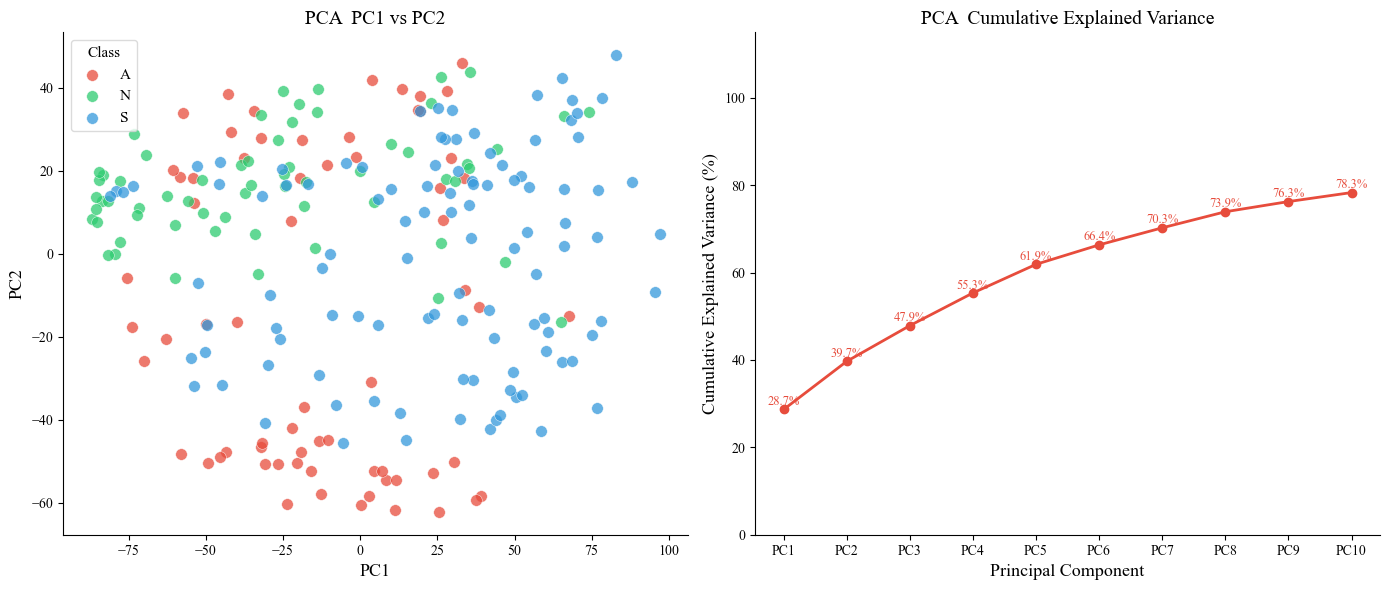

PC1: 28.67%  |  Cumulative: 28.67%
PC2: 11.02%  |  Cumulative: 39.69%
PC3: 8.18%  |  Cumulative: 47.87%
PC4: 7.48%  |  Cumulative: 55.35%
PC5: 6.55%  |  Cumulative: 61.90%
PC6: 4.45%  |  Cumulative: 66.35%
PC7: 3.90%  |  Cumulative: 70.25%
PC8: 3.68%  |  Cumulative: 73.93%
PC9: 2.33%  |  Cumulative: 76.26%
PC10: 2.07%  |  Cumulative: 78.33%


In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca_plot = PCA(n_components=10)
pca_plot.fit(x_scaled.T)
X_pca_plot = pca_plot.transform(x_scaled.T)

colors_map = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
labels_map = {0: 'A', 1: 'N', 2: 'S'}

plt.rcParams['font.family'] = 'Times New Roman'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
for cls in [0, 1, 2]:
    mask = Y1_code.values.ravel() == cls
    ax1.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1],
                c=colors_map[cls], label=labels_map[cls],
                alpha=0.75, edgecolors='white', linewidths=0.4, s=70)

ax1.set_xlabel('PC1', fontsize=13)
ax1.set_ylabel('PC2', fontsize=13)
ax1.set_title('PCA  PC1 vs PC2', fontsize=14)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(False)
ax1.legend(title='Class', fontsize=11, title_fontsize=11,
           frameon=True, edgecolor='lightgray')

ax2 = axes[1]
expl  = pca_plot.explained_variance_ratio_
cumul = np.cumsum(expl)
pcs   = [f'PC{i+1}' for i in range(len(expl))]

ax2.plot(pcs, cumul * 100, color='#E74C3C', marker='o',
         linewidth=2, markersize=6)

for i, c in enumerate(cumul):
    ax2.text(i, c * 100 + 1.0, f'{c*100:.1f}%', ha='center', fontsize=9, color='#E74C3C')

ax2.set_xlabel('Principal Component', fontsize=13)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=13)
ax2.set_title('PCA  Cumulative Explained Variance', fontsize=14)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(False)
ax2.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('PCA_variance.png', dpi=300, bbox_inches='tight')
plt.show()

for i, (e, c) in enumerate(zip(expl, cumul)):
    print(f"PC{i+1}: {e*100:.2f}%  |  Cumulative: {c*100:.2f}%")

<font color=#EF5DCC size=9>**Supervised Learning**

<font color=#AD85E9 size=6>**Support vector machine (SVM)**
    
<font color=#858FE1 size=3>**supervised learning**

<font color=E3B4F2 size=3>**Model 80:20**

In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV #permite realizar una búsqueda exhaustiva en un conjunto de parámetros especificados por el usuario para encontrar los mejores hiperparámetros del modelo.
from sklearn.metrics import accuracy_score #permite calcular la precisión de un modelo de clasificación

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(x_scaled.T, Y1_code.values.ravel(), train_size   = 0.8, random_state = 12, shuffle = True)

modelo2 = SVC(C = 40, kernel = 'rbf', random_state=200)
modelo2.fit(X_tr2, y_tr2)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",40
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
# Predictions

predicciones = modelo2.predict(X_te2)
predicciones

array([0., 0., 1., 1., 0., 2., 2., 2., 1., 2., 2., 0., 2., 1., 0., 1., 2.,
       0., 2., 0., 2., 2., 0., 2., 1., 2., 0., 1., 0., 1., 1., 2., 0., 2.,
       2., 0., 1., 2., 1., 1., 0., 2., 0., 2., 0., 2., 2., 0.])

In [21]:
# Accuracy of the model

accuracy = accuracy_score(y_true = y_te2, y_pred = predicciones, normalize = True)
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 95.83333333333334%


<font color=#AD85E9 size=3>**Metrics for the confusion matrix**
    

In [22]:
from sklearn.linear_model import LinearRegression

# Fit the model to the training data
clf = LinearRegression().fit(X_tr2, y_tr2)

# Print the weight coefficients
print(clf.coef_)

[ 0.00120426  0.00031617 -0.00112315 ... -0.00021237 -0.00032863
 -0.00058428]


In [23]:
def opt_svc(X, y, xt, yt, rs):

    # Definición y entrenamiento del modelo SVC
    svc = SVC(C=40, kernel='rbf', random_state=rs)
    svc.fit(X, y)
    y_pred = svc.predict(xt)

    # Cálculo de la métrica
    ex = accuracy_score(y_true=yt, y_pred=y_pred, normalize=True)

    return (y_pred, ex)

In [24]:
# Testing with distintos random states

exs = []
yps = []
rss = []
arr_rs = np.arange(1, 200)

for rs in arr_rs:
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled.T, Y1_code.values.ravel(),
        train_size=0.8, random_state=rs, shuffle=True
    )
    y_pred, ex = opt_svc(x_train, y_train, x_test, y_test, rs)
    rss.append(rs)
    yps.append(y_pred)
    exs.append(ex)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled.T, Y1_code.values.ravel(), train_size   = 0.8, random_state = rss[np.argmax(exs)], shuffle = True)

# Creación del modelo SVM 

svc1 = SVC(C = 40, kernel = 'rbf', random_state=123)
svc1.fit(x_train, y_train)
y_pred_svc = svc1.predict(x_test)
ex_svc = accuracy_score(y_true = y_test, y_pred = y_pred_svc, normalize = True)
ex_svc

1.0

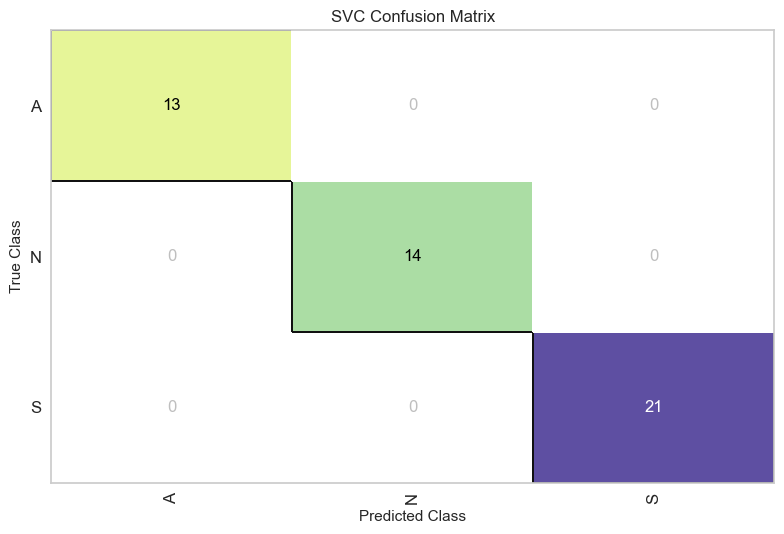

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000        13
         1.0     1.0000    1.0000    1.0000        14
         2.0     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48



<Figure size 800x550 with 0 Axes>

In [26]:
from yellowbrick.classifier import confusion_matrix
from tabulate import tabulate as tabulate_fn

confusion_matrix(
    SVC(C = 40, kernel = 'rbf', random_state=123),
    x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
) 

plt.savefig('CM_SVC.png');
plt.tight_layout();

from sklearn import metrics
print(metrics.classification_report(y_test,y_pred_svc, digits = 4))

In [27]:
np.max(exs), rss[np.argmax(exs)]

(np.float64(1.0), np.int64(42))

<font color=#D63BB0 size=6>**Nu-Support Vector Classification (NuSVM)**

In [28]:
from sklearn.svm import NuSVC

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(x_scaled.T, Y1_code.values.ravel(), train_size = 0.8, random_state = 12, shuffle = True)

modeloNu = NuSVC(nu=0.1, gamma='auto')
modeloNu.fit(X_tr2, y_tr2)

,"nu nu: float, default=0.5An upper bound on the fraction of margin errors (see :ref:`User Guide`) and a lower bound of the fraction of support vectors.Should be in the interval (0, 1].",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: {dict, 'balanced'}, default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one. The ""balanced"" mode uses the values of y to automaticallyadjust weights inversely proportional to class frequencies as``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


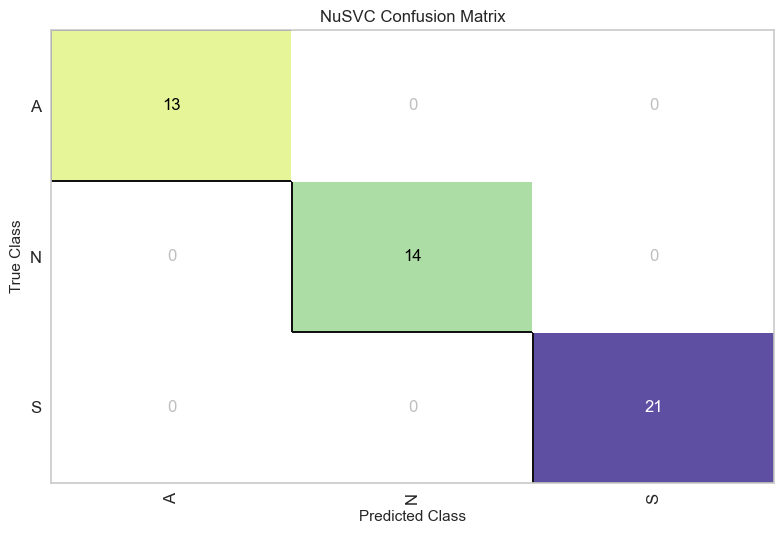

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000        13
         1.0     1.0000    1.0000    1.0000        14
         2.0     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48



<Figure size 800x550 with 0 Axes>

In [29]:
from yellowbrick.classifier import confusion_matrix
confusion_matrix(
   NuSVC(nu=0.1, gamma='auto'),
    x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
) 
plt.savefig('CM_NuSVC.png')
plt.tight_layout();

#Predicción con base a las variables ya entrenadas

y_predNu = modeloNu.predict(x_test)

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_predNu, digits = 4))


<font color=#D63BB0 size=6>**Linear Support Vector Classification**

In [30]:
from sklearn.svm import LinearSVC


x_train, x_test, y_train, y_test = train_test_split(
    x_scaled.T, Y1_code.values.ravel(),
    train_size=0.8, random_state=rss[np.argmax(exs)], shuffle=True
)

# Creación del modelo linearSVM 
LiSVC = LinearSVC(max_iter=5000, dual='auto')
LiSVC.fit(x_train, y_train)

y_pred_lisvc = LiSVC.predict(x_test)
Lisvc = accuracy_score(y_true=y_test, y_pred=y_pred_lisvc, normalize=True)
Lisvc

0.9791666666666666

In [31]:
# Predictions
p = y_pred_lisvc

C:\Users\nephi\anaconda3\envs\spring2026\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


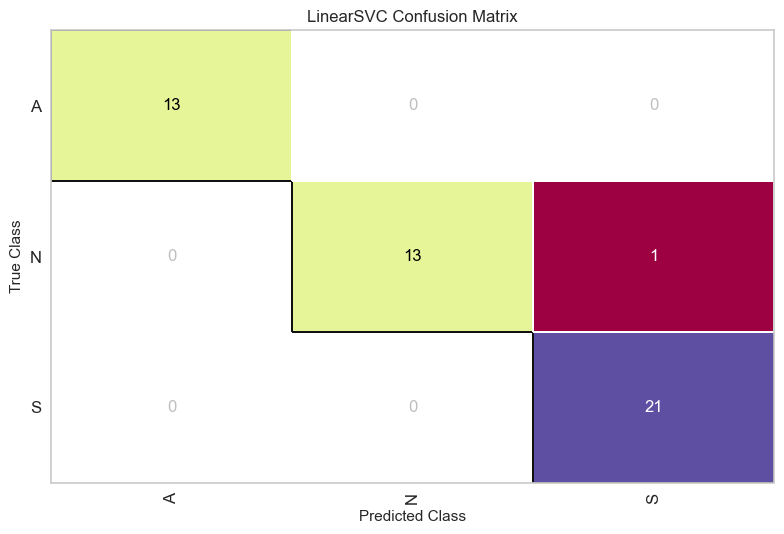

<Figure size 800x550 with 0 Axes>

In [32]:
from yellowbrick.classifier import confusion_matrix
confusion_matrix(
    LinearSVC (), x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
) 
plt.savefig('CM_LinearSVC.png')
plt.tight_layout();

In [33]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
confusion_matrix(y_test, p)

array([[13,  0,  0],
       [ 0, 13,  1],
       [ 0,  0, 21]])

In [34]:
#Generación de soporte

print(metrics.classification_report(y_test, p, digits = 4))

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000        13
         1.0     1.0000    0.9286    0.9630        14
         2.0     0.9545    1.0000    0.9767        21

    accuracy                         0.9792        48
   macro avg     0.9848    0.9762    0.9799        48
weighted avg     0.9801    0.9792    0.9790        48



<font color=#AD85E9 size=8>**Neural networks (Redes Neuronales)**



In [35]:
from sklearn.neural_network import MLPClassifier
x_train, x_test, y_train, y_test = train_test_split(x_scaled.T, Y1_code.values.ravel(), train_size=0.8, random_state=rss[np.argmax(exs)], shuffle= True)
ann = MLPClassifier(hidden_layer_sizes=(20, 20), learning_rate_init=0.01, solver = 'lbfgs', max_iter = 5000, random_state = 123)
ann.fit(X=x_train, y=y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",5000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",123


In [36]:
#Predicción con base a las variables ya entrenadas

y_pred = ann.predict(x_test)
score = ann.score(x_test, y_test)
score

0.8958333333333334

In [37]:
#Matriz de confusion para saber donde acierta y donde falla

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
confusion_matrix(y_test, y_pred)

array([[11,  2,  0],
       [ 1, 12,  1],
       [ 0,  1, 20]])

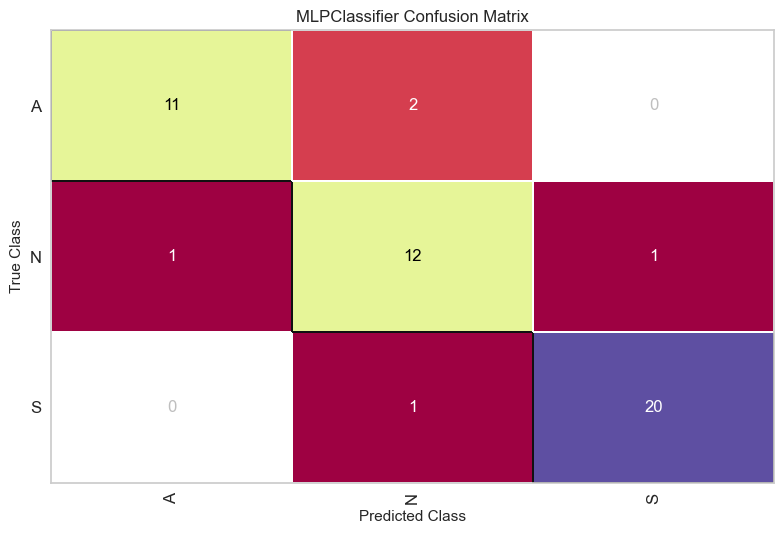

              precision    recall  f1-score   support

         0.0     0.9167    0.8462    0.8800        13
         1.0     0.8000    0.8571    0.8276        14
         2.0     0.9524    0.9524    0.9524        21

    accuracy                         0.8958        48
   macro avg     0.8897    0.8852    0.8867        48
weighted avg     0.8983    0.8958    0.8964        48



<Figure size 800x550 with 0 Axes>

In [38]:
from yellowbrick.classifier import confusion_matrix

confusion_matrix(
    MLPClassifier(hidden_layer_sizes=(20, 20), learning_rate_init=0.01, solver = 'lbfgs', max_iter = 5000, random_state = 123),
    x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
) 
plt.savefig('CM_MLPclassifier_neural networks.png')
plt.tight_layout();

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_pred, digits = 4))

# SAVING THE MODELS

In [39]:
# Guardar el modelo entrenado. 
# Primero el SVC y segundo la red neuronal

import joblib

File_svc = "Mod_chagas_svc.pkl"
joblib.dump(svc1, File_svc)

['Mod_chagas_svc.pkl']

In [40]:
File_ann = "Mod_chagas_ann.pkl"
joblib.dump(ann, File_ann)

['Mod_chagas_ann.pkl']

In [41]:
Model_svc = joblib.load('Mod_chagas_svc.pkl')

In [42]:
Model_svc

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",40
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [43]:
Model_red = joblib.load('Mod_chagas_ann.pkl')
Model_red

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",5000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",123


 <font color=#CF3BD6 size=8>**Classifiers**

 <font color=#E188CC size=6>**Random Forest**
    

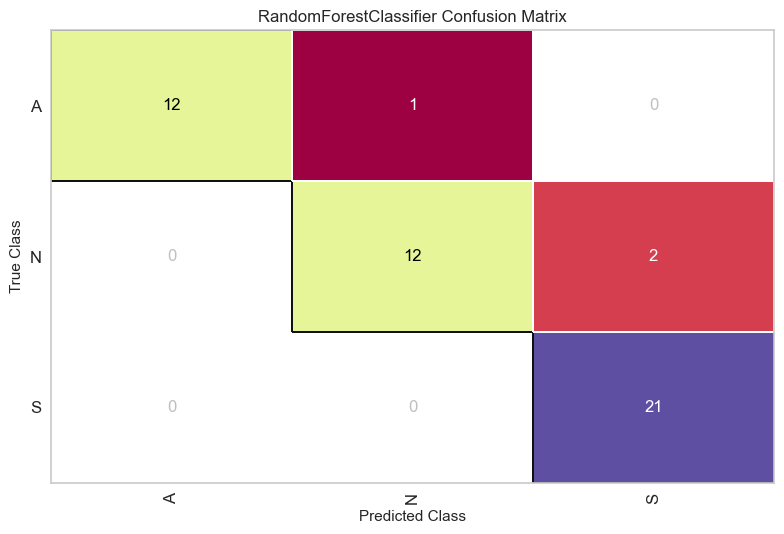

              precision    recall  f1-score   support

         0.0     1.0000    0.9231    0.9600        13
         1.0     0.9231    0.8571    0.8889        14
         2.0     0.9130    1.0000    0.9545        21

    accuracy                         0.9375        48
   macro avg     0.9454    0.9267    0.9345        48
weighted avg     0.9395    0.9375    0.9369        48



<Figure size 800x550 with 0 Axes>

In [44]:
from yellowbrick.classifier import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=90)
rfc.fit(x_train, y_train)

confusion_matrix(
   RandomForestClassifier(random_state = 90),
    x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
) 

plt.savefig('CM_RandomForest.png')
plt.tight_layout();

#Predicción con base a las variables ya entrenadas

y_pred1 = rfc.predict(x_test)


#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_pred1, digits = 4))

 <font color=#E188CC size=6>**XG BOOST**

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=200)
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [46]:
y_pred2 = xgb.predict(x_test)
score_xgb = xgb.score(x_test, y_test)
score_xgb

0.9166666666666666

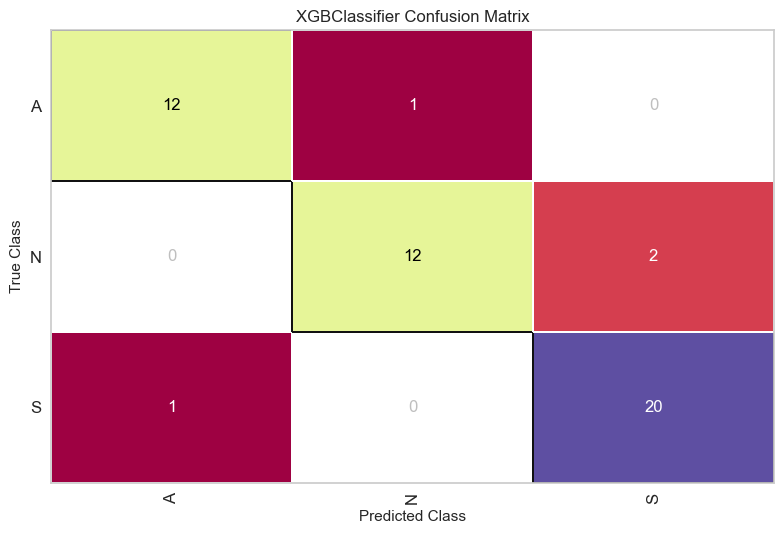

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     0.9231    0.9231    0.9231        13
         1.0     0.9231    0.8571    0.8889        14
         2.0     0.9091    0.9524    0.9302        21

    accuracy                         0.9167        48
   macro avg     0.9184    0.9109    0.9141        48
weighted avg     0.9170    0.9167    0.9162        48



In [47]:
from yellowbrick.classifier import confusion_matrix

visualizer = confusion_matrix(
    xgb
    , x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'],  cmap='Spectral',
    force_model=True
   )

plt.savefig('CM_XGB.png')
plt.tight_layout();
plt.show()

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_pred2, digits = 4))

 <font color=#973BD6 size=6>**Stochastic Gradient Descent-Classifier (SGDClassifier)**

In [48]:
from sklearn.linear_model import SGDClassifier

sgdc = SGDClassifier(max_iter=2000, tol=1e-3, early_stopping=True, n_iter_no_change=10)

sgdc.fit(x_train, y_train)

y_pred_sgdc = sgdc.predict(x_test)
score_sgdc = sgdc.score(x_test, y_test)

print("Accuracy:", score_sgdc)

Accuracy: 0.9583333333333334


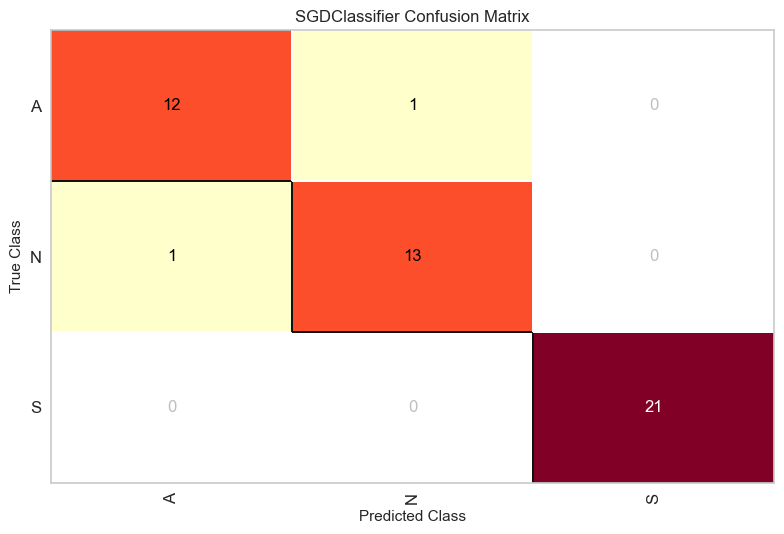

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     0.9231    0.9231    0.9231        13
         1.0     0.9286    0.9286    0.9286        14
         2.0     1.0000    1.0000    1.0000        21

    accuracy                         0.9583        48
   macro avg     0.9505    0.9505    0.9505        48
weighted avg     0.9583    0.9583    0.9583        48



In [49]:
from yellowbrick.classifier import confusion_matrix

visualizer = confusion_matrix(
    sgdc, x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], #cmap='Spectral'
    force_model=True
)

plt.savefig('sdg.png')
plt.tight_layout();
plt.show()

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_pred_sgdc, digits = 4))

 <font color=#E188CC size=6>**K-Nearest Neighbors(KNN)**

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

In [51]:
knc = KNeighborsClassifier()
knc.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [52]:
y_pred3 = knc.predict(x_test)
score_knc = knc.score(x_test, y_test)
score_knc

0.8333333333333334

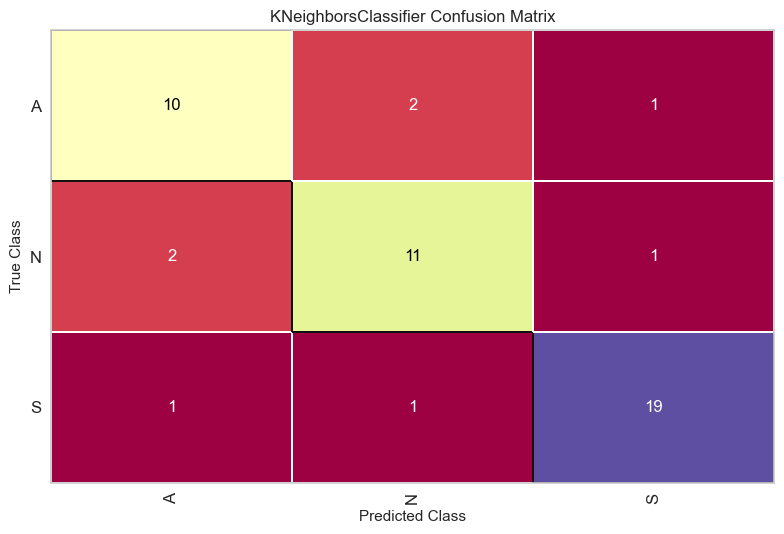

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     0.7692    0.7692    0.7692        13
         1.0     0.7857    0.7857    0.7857        14
         2.0     0.9048    0.9048    0.9048        21

    accuracy                         0.8333        48
   macro avg     0.8199    0.8199    0.8199        48
weighted avg     0.8333    0.8333    0.8333        48



<Figure size 800x550 with 0 Axes>

In [53]:
from yellowbrick.classifier import confusion_matrix

visualizer = confusion_matrix(
    knc, x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
)
plt.tight_layout();
plt.show()
plt.savefig('CM_KNN.png')

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, y_pred3, digits = 4))

 <font color=#E188CC size=6>**Logistic Regression**

In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
ypred_lr=lr.predict(x_test)
lr.score(x_test, y_test)
#print(classification_report(y_test,ypred))

0.9583333333333334

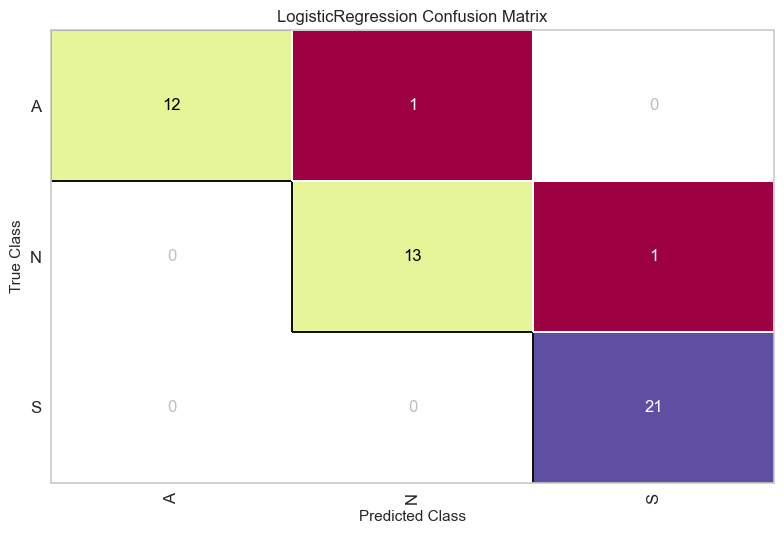

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     1.0000    0.9231    0.9600        13
         1.0     0.9286    0.9286    0.9286        14
         2.0     0.9545    1.0000    0.9767        21

    accuracy                         0.9583        48
   macro avg     0.9610    0.9505    0.9551        48
weighted avg     0.9593    0.9583    0.9582        48



In [56]:
from yellowbrick.classifier import confusion_matrix

visualizer = confusion_matrix(
    lr, x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
)



plt.savefig('CM_LogisticRegression.png')
plt.tight_layout();
plt.show()



#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, ypred_lr, digits = 4))

 <font color=#C499F3 size=6>**Bagging Classifier**

In [57]:
from sklearn.ensemble import BaggingClassifier

B =  BaggingClassifier()
B.fit(x_train, y_train)

ypred_B=B.predict(x_test)

print('Score: %.2f' % B.score(x_test, y_test))

Score: 0.94


In [58]:
#Matriz de confusion para saber donde acierta y donde falla

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
confusion_matrix(y_test, ypred_B)

array([[13,  0,  0],
       [ 0, 12,  2],
       [ 1,  0, 20]])

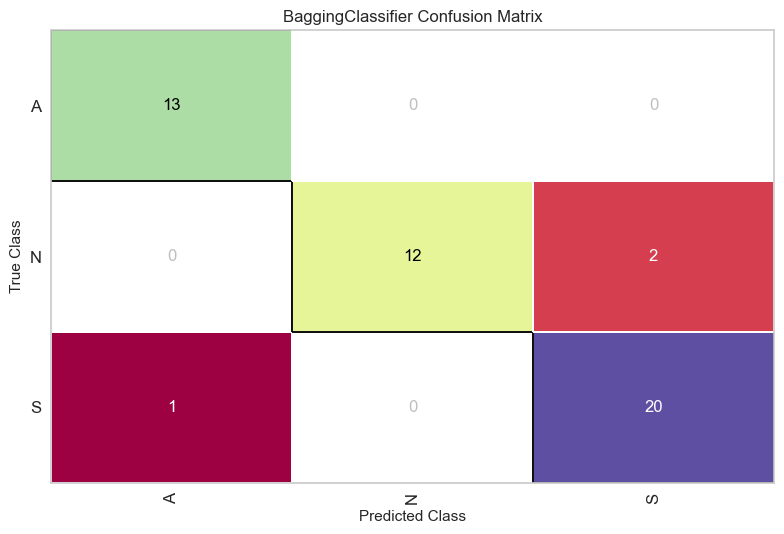

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     0.9286    1.0000    0.9630        13
         1.0     1.0000    0.8571    0.9231        14
         2.0     0.9091    0.9524    0.9302        21

    accuracy                         0.9375        48
   macro avg     0.9459    0.9365    0.9388        48
weighted avg     0.9409    0.9375    0.9370        48



<Figure size 800x550 with 0 Axes>

In [59]:
from yellowbrick.classifier import confusion_matrix

visualizer = confusion_matrix(
    B, x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
)
plt.tight_layout();
plt.show()
plt.savefig('CM_BeggingClassifier.png')


#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, ypred_B, digits = 4))

 <font color=#C21292 size=6>**ExtraTrees Classifier**

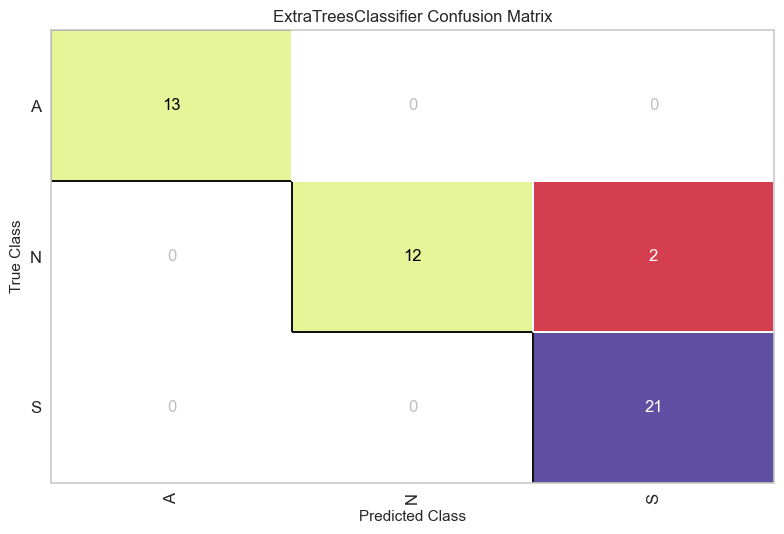

<Figure size 800x550 with 0 Axes>

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000        13
         1.0     1.0000    0.8571    0.9231        14
         2.0     0.9130    1.0000    0.9545        21

    accuracy                         0.9583        48
   macro avg     0.9710    0.9524    0.9592        48
weighted avg     0.9620    0.9583    0.9577        48



<Figure size 800x550 with 0 Axes>

In [60]:
from sklearn.ensemble import ExtraTreesClassifier

T = ExtraTreesClassifier(n_estimators=300)
T.fit(x_train, y_train)

ypred_T=T.predict(x_test)

visualizer = confusion_matrix(
    T, x_train, y_train, x_test, y_test,
    classes=['A', 'N', 'S'], cmap='Spectral',
    force_model=True
)
plt.tight_layout();
plt.show()
plt.savefig('CM_ExtraTrees.png')

#Generación de soporte

from sklearn import metrics
print(metrics.classification_report(y_test, ypred_T, digits = 4))

 <font color=#E188CC size=6>**Comparation of the different Models and Quantifiers**

SVC: 1.0000
NuSVC: 1.0000
LinearSVC: 0.9792
SGDClassifier: 0.7500
KNeighborsClassifier: 0.8333
MLPClassifier: 0.8958
ExtraTreesClassifier: 0.9375
BaggingClassifier: 0.9375
RandomForestClassifier: 0.9375
LogisticRegression: 0.9583
XGBClassifier: 0.9167


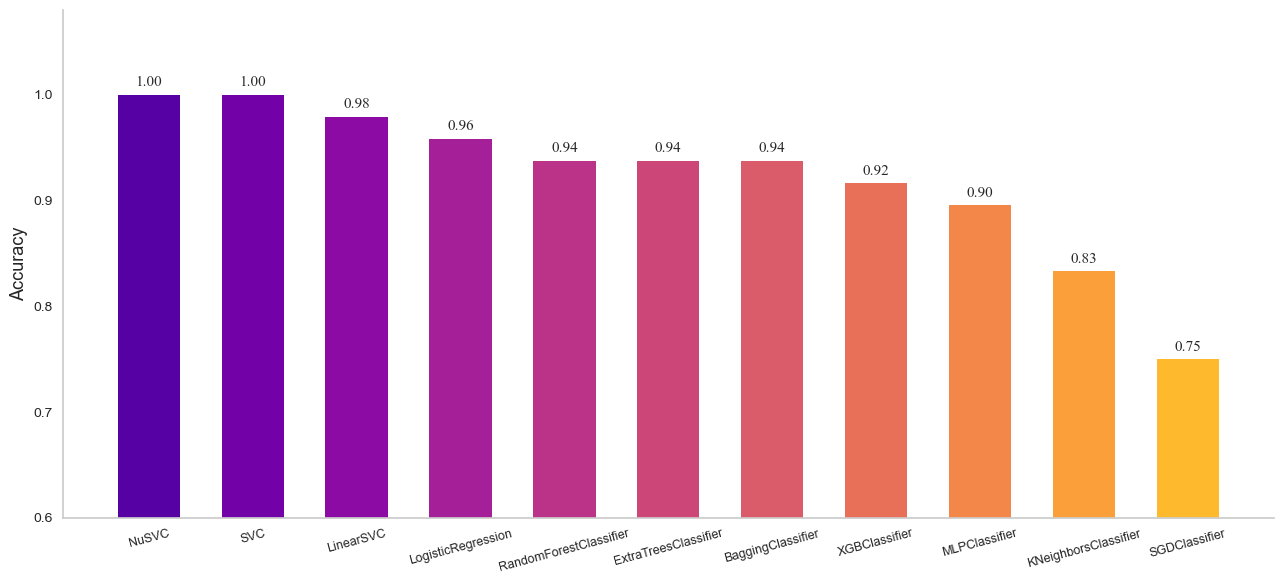

In [61]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, NuSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

models = [
    SVC(gamma='auto', C=40, kernel='rbf', random_state=123),
    NuSVC(nu=0.1, gamma='auto'),
    LinearSVC(max_iter=5000, dual='auto'),
    SGDClassifier(max_iter=2000, tol=1e-3),
    KNeighborsClassifier(),
    MLPClassifier(hidden_layer_sizes=(20, 20), learning_rate_init=0.01, solver='lbfgs', max_iter=5000, random_state=123),
    ExtraTreesClassifier(n_estimators=300),
    BaggingClassifier(),
    RandomForestClassifier(n_estimators=300),
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=123),
    XGBClassifier(random_state=200)
]

names, accuracies = [], []

for model in models:
    pipe = Pipeline([('estimator', model)])
    pipe.fit(x_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(x_test))
    names.append(model.__class__.__name__)
    accuracies.append(acc)
    print(f"{model.__class__.__name__}: {acc:.4f}")


order          = np.argsort(accuracies)[::-1]
names_sorted   = [names[i] for i in order]
acc_sorted     = [accuracies[i] for i in order]


colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(names_sorted)))
fig, ax = plt.subplots(figsize=(13, 6))
plt.rcParams['font.family'] = 'Times New Roman'

bars = ax.bar(names_sorted, acc_sorted, color=colors, width=0.6)

for bar, val in zip(bars, acc_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)
ax.grid(False)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_ylim(0.6, 1.08)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelsize=9, rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<font color=#85C1E9 size=8>**ROC Curves**

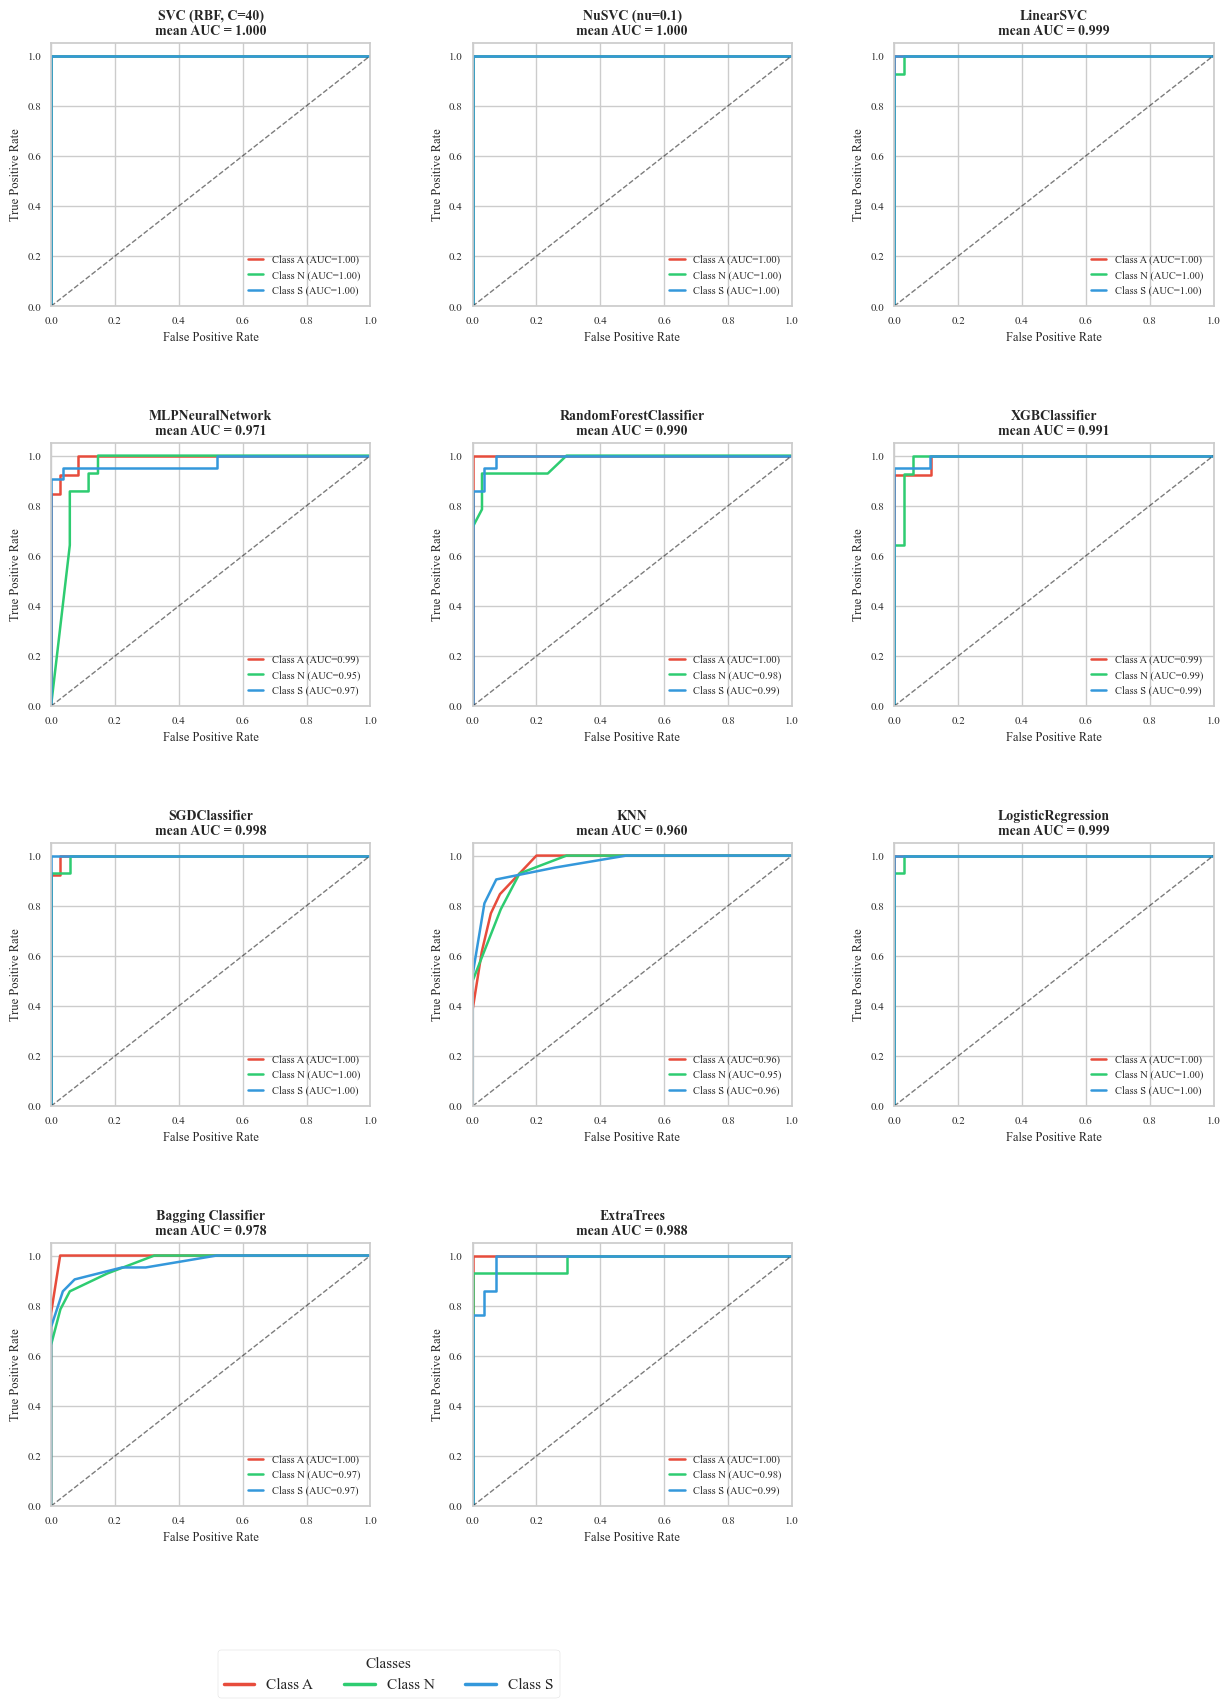

In [62]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import NuSVC, LinearSVC
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np


CLASSES      = [0, 1, 2]
CLASS_NAMES  = ['A', 'N', 'S']
COLORS       = ['#E74C3C', '#2ECC71', '#3498DB']   # rojo, verde, azul
plt.rcParams['font.family'] = 'Times New Roman'

# Binarizar etiquetas
y_bin = label_binarize(y_test.astype(int), classes=CLASSES)

# Entrenar modelos que requieren probability / calibración 
svc_prob = SVC(C=40, kernel='rbf', random_state=123, probability=True)
svc_prob.fit(x_train, y_train)

nusvc_prob = NuSVC(nu=0.1, gamma='auto', probability=True)
nusvc_prob.fit(x_train, y_train)

lisvc_cal = CalibratedClassifierCV(LinearSVC(max_iter=10000), cv=5)
lisvc_cal.fit(x_train, y_train)

sgdc_cal = CalibratedClassifierCV(
    SGDClassifier(max_iter=1000, tol=1e-3, early_stopping=True, n_iter_no_change=10), cv=5
)
sgdc_cal.fit(x_train, y_train)

# Lista de modelos (nombre, predict_proba)
models_roc = [
    ('SVC (RBF, C=40)',      svc_prob.predict_proba),     # F1-C1
    ('NuSVC (nu=0.1)',        nusvc_prob.predict_proba),   # F1-C2
    ('LinearSVC',             lisvc_cal.predict_proba),    # F1-C3
    ('MLPNeuralNetwork',      ann.predict_proba),          # F2-C1
    ('RandomForestClassifier',rfc.predict_proba),          # F2-C2
    ('XGBClassifier',         xgb.predict_proba),          # F2-C3
    ('SGDClassifier',         sgdc_cal.predict_proba),     # F3-C1
    ('KNN',                   knc.predict_proba),          # F3-C2
    ('LogisticRegression',    lr.predict_proba),           # F3-C3
    ('Bagging Classifier',    B.predict_proba),            # F4-C1
    ('ExtraTrees',            T.predict_proba),            # F4-C2
]

'cuadricula'
N_ROWS, N_COLS = 4, 3
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 19))
plt.subplots_adjust(hspace=0.52, wspace=0.32)

for idx, (name, proba_fn) in enumerate(models_roc):
    row, col = divmod(idx, N_COLS)
    ax = axes[row, col]

    y_score  = proba_fn(x_test)
    aucs     = []

    for i, (cname, color) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'Class {cname} (AUC={roc_auc:.2f})')

    mean_auc = np.mean(aucs)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.55)
    ax.set_xlim([0.0, 1.0]);  ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate',  fontsize=9)
    ax.set_title(f'{name}\nmean AUC = {mean_auc:.3f}',
                 fontsize=10, fontweight='bold', pad=6)
    ax.legend(loc='lower right', fontsize=7.5, framealpha=0.85,
              handlelength=1.5, borderpad=0.5)
    ax.tick_params(labelsize=8)

# Ocultar subplot vacío (fila 4, columna 3) 
axes[3, 2].set_visible(False)

legend_handles = [
    mlines.Line2D([], [], color=COLORS[0], lw=2.5, label='Class A'),
    mlines.Line2D([], [], color=COLORS[1], lw=2.5, label='Class N'),
    mlines.Line2D([], [], color=COLORS[2], lw=2.5, label='Class S'),
]
fig.legend(handles=legend_handles,
           loc='lower center',
           ncol=3,
           fontsize=11,
           title='Classes',
           title_fontsize=11,
           frameon=True,
           bbox_to_anchor=(0.35, 0.005))

plt.savefig('ROC_all_11_models.png', dpi=150, bbox_inches='tight')
plt.show()


Nodes: 236  |  Edges: 241


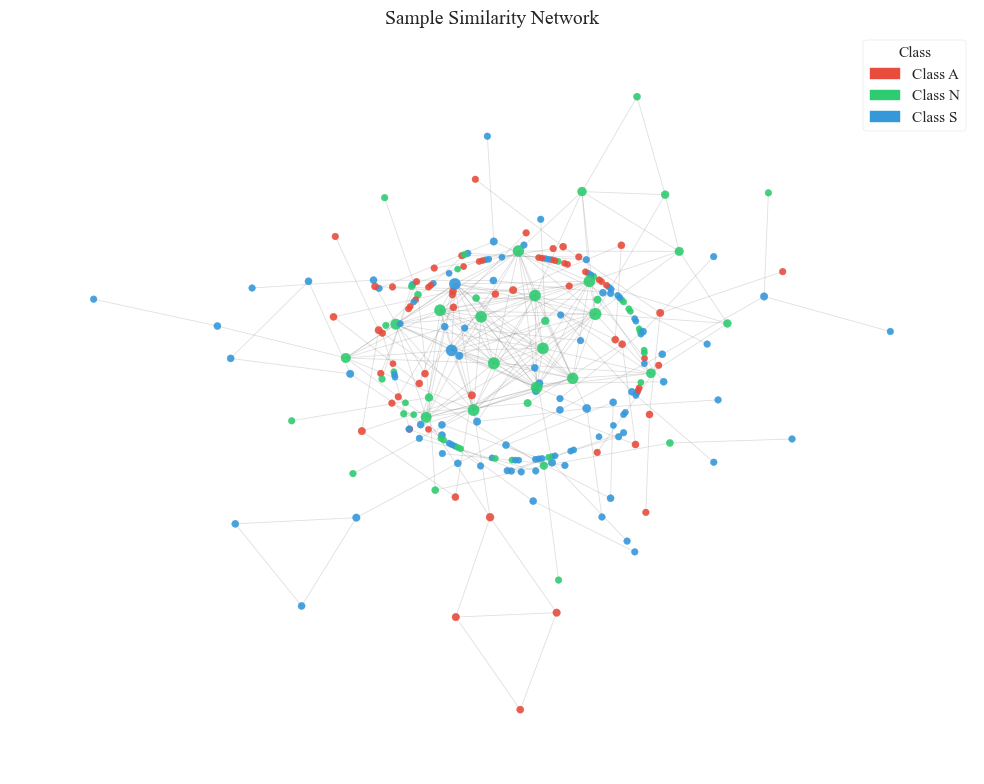

Modularity: 0.4061
Class A — internal density: 0.0163
Class N — internal density: 0.0592
Class S — internal density: 0.0088


In [63]:
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pca_graph = PCA(n_components=10)
X_pca = pca_graph.fit_transform(x_scaled.T)

threshold = 0.93
sim_matrix = cosine_similarity(X_pca)

G = nx.Graph()
labels = Y1_code.values.ravel()

for i in range(len(X_pca)):
    G.add_node(i, label=int(labels[i]))

for i in range(len(X_pca)):
    for j in range(i + 1, len(X_pca)):
        if sim_matrix[i, j] >= threshold:
            G.add_edge(i, j, weight=sim_matrix[i, j])

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

plt.rcParams['font.family'] = 'Times New Roman'

NODE_COLORS_MAP = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
CLASS_NAMES     = {0: 'A', 1: 'N', 2: 'S'}

node_colors = [NODE_COLORS_MAP[G.nodes[n]['label']] for n in G.nodes]
degree      = dict(G.degree())
node_sizes  = [degree[n] * 3 + 20 for n in G.nodes]

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)

patches = [mpatches.Patch(color=NODE_COLORS_MAP[c], label=f'Class {CLASS_NAMES[c]}')
           for c in [0, 1, 2]]
ax.legend(handles=patches, fontsize=11, title='Class', title_fontsize=11,
          frameon=True, edgecolor='lightgray')

ax.set_title('Sample Similarity Network', fontsize=14)
ax.axis('off')
ax.grid(False)

plt.tight_layout()
plt.savefig('GraphML_PoC.png', dpi=300, bbox_inches='tight')
plt.show()

communities = [{n for n in G.nodes if G.nodes[n]['label'] == c} for c in [0, 1, 2]]
mod = nx.algorithms.community.modularity(G, communities)
print(f"Modularity: {mod:.4f}")

for c in [0, 1, 2]:
    nodes_c = [n for n in G.nodes if G.nodes[n]['label'] == c]
    subG    = G.subgraph(nodes_c)
    print(f"Class {CLASS_NAMES[c]} — internal density: {nx.density(subG):.4f}")

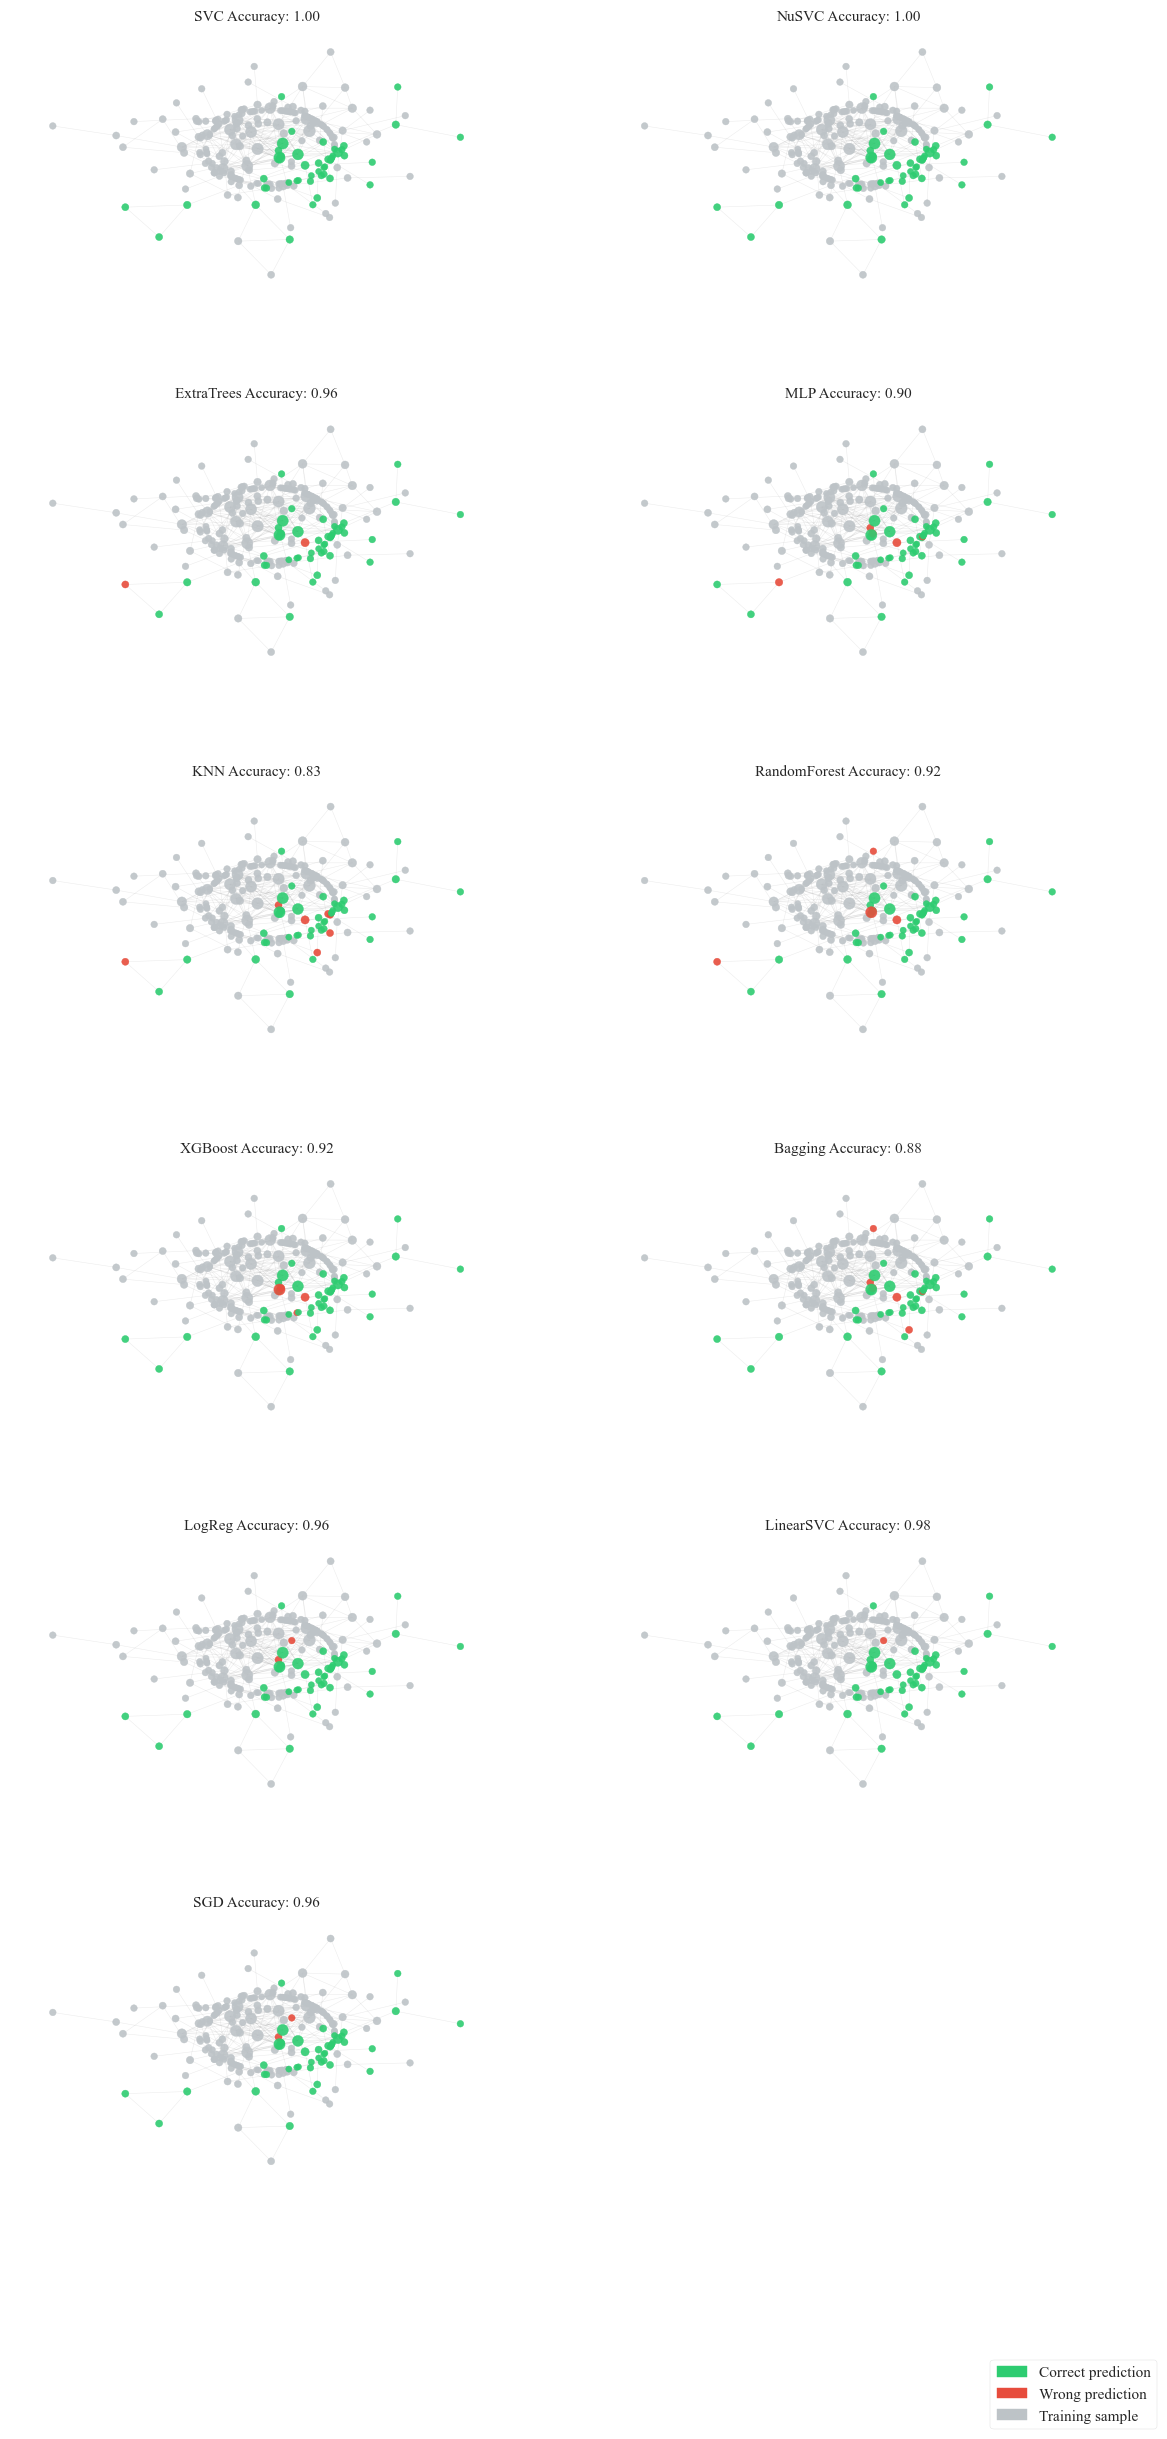

In [64]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


models_poc = [
    ('SVC',          SVC(C=40, kernel='rbf', random_state=123)),
    ('NuSVC',        NuSVC(nu=0.1, gamma='auto')),
    ('ExtraTrees',   ExtraTreesClassifier(n_estimators=300)),
    ('MLP',          MLPClassifier(hidden_layer_sizes=(20,20), learning_rate_init=0.01, solver='lbfgs', max_iter=5000, random_state=123)),
    ('KNN',          KNeighborsClassifier()),
    ('RandomForest', RandomForestClassifier(n_estimators=300)),
    ('XGBoost',      XGBClassifier(random_state=200)),
    ('Bagging',      BaggingClassifier()),
    ('LogReg',       LogisticRegression(solver='lbfgs', max_iter=1000, random_state=123)),
    ('LinearSVC',    LinearSVC(max_iter=5000, dual='auto')),
    ('SGD',          SGDClassifier(max_iter=2000, tol=1e-3)),
]


pca_graph  = PCA(n_components=10)
X_pca      = pca_graph.fit_transform(x_scaled.T)
sim_matrix = cosine_similarity(X_pca)
threshold  = 0.93

G = nx.Graph()
for i in range(len(X_pca)):
    G.add_node(i)
for i in range(len(X_pca)):
    for j in range(i + 1, len(X_pca)):
        if sim_matrix[i, j] >= threshold:
            G.add_edge(i, j, weight=sim_matrix[i, j])

pos    = nx.kamada_kawai_layout(G)
degree = dict(G.degree())
node_sizes = [degree[n] * 3 + 20 for n in G.nodes]


plt.rcParams['font.family'] = 'Times New Roman'
fig, axes = plt.subplots(6, 2, figsize=(14, 28))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

correct_color   = '#2ECC71'  # green  = correct prediction
incorrect_color = '#E74C3C'  # red    = wrong prediction

for idx, (name, model) in enumerate(models_poc):
    row, col = divmod(idx, 2)
    ax = axes[row][col]

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Map test indices to graph nodes (test set = last len(x_test) samples after split)
    test_indices = np.where(~np.isin(np.arange(x_scaled.T.shape[0]),
                            np.arange(x_train.shape[0])))[0]

    node_colors = []
    for n in G.nodes:
        if n in test_indices:
            pos_in_test = np.where(test_indices == n)[0]
            if len(pos_in_test) > 0:
                correct = (y_pred[pos_in_test[0]] == y_test[pos_in_test[0]])
                node_colors.append(correct_color if correct else incorrect_color)
            else:
                node_colors.append('#BDC3C7')
        else:
            node_colors.append('#BDC3C7')  # gray = training sample

    acc = accuracy_score(y_test, y_pred)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.4, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.9)

    ax.set_title(f'{name} Accuracy: {acc:.2f}', fontsize=11, fontweight='500')
    ax.axis('off')
    ax.grid(False)


axes[5][1].set_visible(False)


patches = [
    mpatches.Patch(color=correct_color,   label='Correct prediction'),
    mpatches.Patch(color=incorrect_color, label='Wrong prediction'),
    mpatches.Patch(color='#BDC3C7',       label='Training sample'),
]
fig.legend(handles=patches, loc='lower right', fontsize=11,
           frameon=True, edgecolor='lightgray',
           bbox_to_anchor=(0.95, 0.02))

plt.savefig('GraphML_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

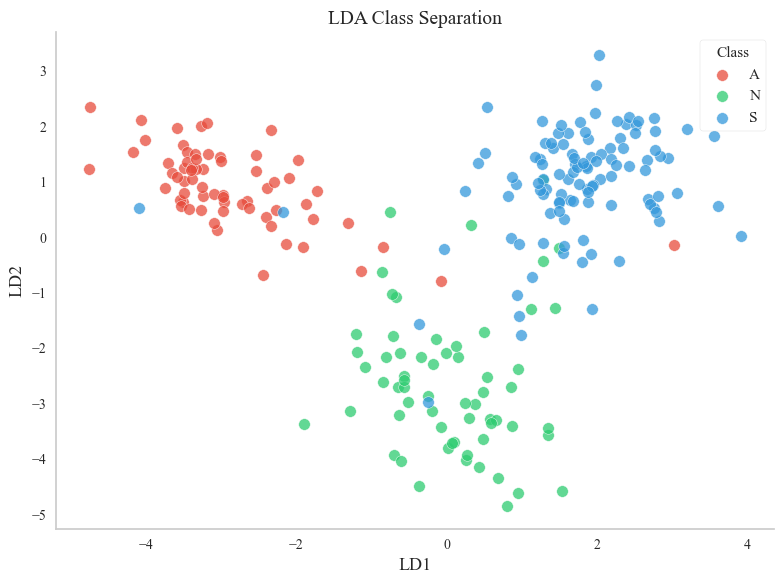

LD1: 59.2%  |  LD2: 40.8%


In [65]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(x_scaled.T, Y1_code.values.ravel())

plt.rcParams['font.family'] = 'Times New Roman'

colors_map = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
labels_map = {0: 'A', 1: 'N', 2: 'S'}

fig, ax = plt.subplots(figsize=(8, 6))

for cls in [0, 1, 2]:
    mask = Y1_code.values.ravel() == cls
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               c=colors_map[cls], label=labels_map[cls],
               alpha=0.75, edgecolors='white', linewidths=0.4, s=70)

ax.set_xlabel('LD1', fontsize=13)
ax.set_ylabel('LD2', fontsize=13)
ax.set_title('LDA Class Separation', fontsize=14)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.legend(title='Class', fontsize=11, title_fontsize=11,
          frameon=True, edgecolor='lightgray')

plt.tight_layout()
plt.savefig('LDA_separation.png', dpi=300, bbox_inches='tight')
plt.show()

explained = lda.explained_variance_ratio_
print(f"LD1: {explained[0]*100:.1f}%  |  LD2: {explained[1]*100:.1f}%")